In [1]:
## Ted Talks

With this project with webscrap

<img src="https://cdn.listelist.com/wp-content/uploads/2017/02/ted.jpg"/>

In [2]:
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [3]:
# 1. KATEGORİ LİSTESİ VE VERİ ÇEKME
def scrape_all_categories(pages_per_cat=3):
    categories = {
        "Tech": "https://ideas.ted.com/category/tech/",
        "Business": "https://ideas.ted.com/category/business/",
        "Arts + Design": "https://ideas.ted.com/category/arts-design/",
        "Science": "https://ideas.ted.com/category/science/",
        "We Humans": "https://ideas.ted.com/category/we-humans/"
    }
    
    all_data = []
    headers = {"User-Agent": "Mozilla/5.0"}

    for cat_name, base_url in categories.items():
        print(f"'{cat_name}' kategorisinden veri çekiliyor...")
        for page in range(1, pages_per_cat + 1):
            url = f"{base_url}page/{page}/"
            try:
                res = requests.get(url, headers=headers, timeout=10)
                if res.status_code != 200: break
                
                soup = BeautifulSoup(res.content, "html.parser")
                articles = soup.find_all(["article", "div"], class_=["post", "type-post"])
                
                for art in articles:
                    title = art.find("h2").get_text(strip=True) if art.find("h2") else None
                    excerpt = art.find("div", class_="entry-content").get_text(strip=True)[:300] if art.find("div", class_="entry-content") else ""
                    if title:
                        all_data.append({
                            "title": title,
                            "category": cat_name,
                            "excerpt": excerpt,
                            "text_for_nlp": f"{title} {excerpt} {cat_name}"
                        })
            except:
                continue
            time.sleep(0.5)
            
    return pd.DataFrame(all_data).drop_duplicates(subset='title').reset_index(drop=True)

In [4]:
# 2. ANALİZ VE GÖRSELLEŞTİRME
def analyze_and_plot(df):
    # NLP İşlemleri
    vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
    tfidf_matrix = vectorizer.fit_transform(df['text_for_nlp'])
    sim_matrix = cosine_similarity(tfidf_matrix)

    # GRAFİK 1: Kategori Dağılımı
    plt.figure(figsize=(10, 5))
    df['category'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='Pastel1')
    plt.title('Veri Setindeki Kategori Dağılımı')
    plt.ylabel('')
    plt.show()

    # GRAFİK 2: TF-IDF Kelime Önem Grafiği
    importance = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
    word_freq = pd.DataFrame({'word': vectorizer.get_feature_names_out(), 'importance': importance})
    top_words = word_freq.sort_values(by='importance', ascending=False).head(15)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_words, x='importance', y='word', hue='word', palette='mako', legend=False)
    plt.title('Kategorilere Göre En Belirleyici Kelimeler')
    plt.show()

    return vectorizer, tfidf_matrix, sim_matrix


'Tech' kategorisinden veri çekiliyor...
'Business' kategorisinden veri çekiliyor...
'Arts + Design' kategorisinden veri çekiliyor...
'Science' kategorisinden veri çekiliyor...
'We Humans' kategorisinden veri çekiliyor...


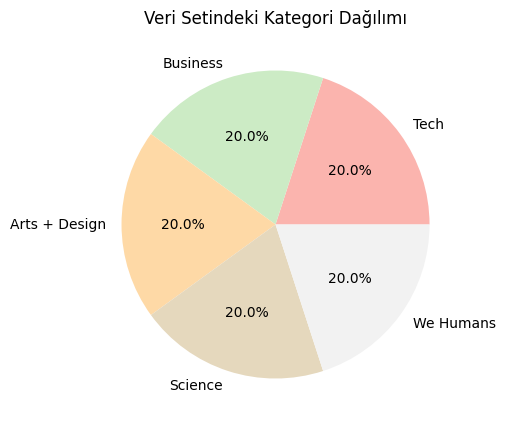

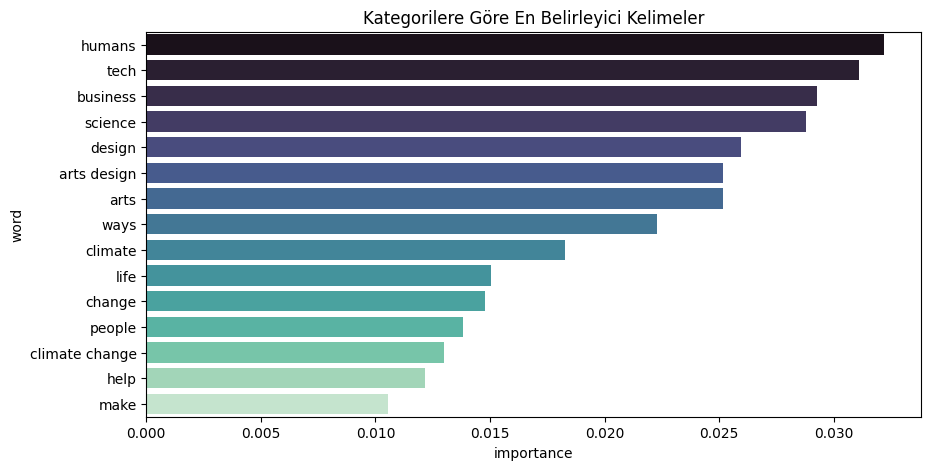


Seçilen Makale: Here’s how you can handle stress like a lion, not a gazelle


In [5]:
# --- ÇALIŞTIRMA ---
df_final = scrape_all_categories(pages_per_cat=5) # Her kategoriden 5 sayfa (Yaklaşık 150-200 makale)

if not df_final.empty:
    vec, mat, sim = analyze_and_plot(df_final)
    
    # Örnek: Rastgele bir 'Science' makalesi seç ve ona öneri bul
    science_articles = df_final[df_final['category'] == 'Science']
    if not science_articles.empty:
        target = science_articles['title'].iloc[0]
        # Daha önce yazdığımız get_recommendations fonksiyonunu burada çağırabilirsin
        print(f"\nSeçilen Makale: {target}")
else:
    print("Veri toplanamadı.")

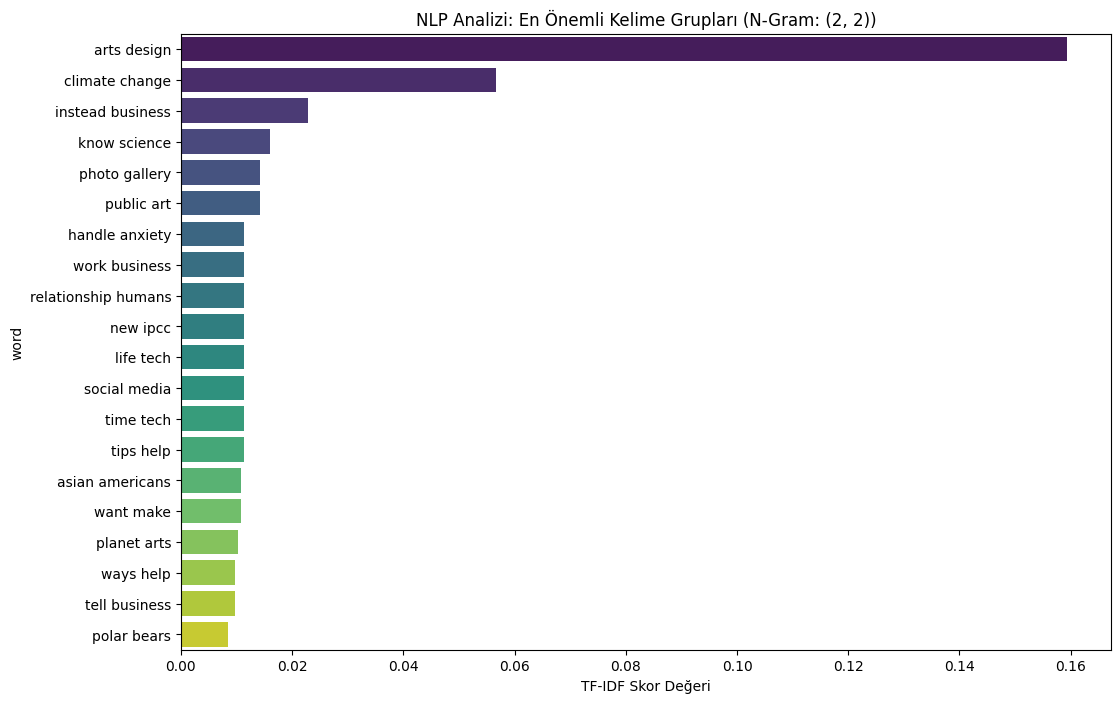

In [7]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

def run_advanced_nlp(df, n_range=(1, 2)):
    if df.empty:
        return None, None, None

    # NLP Modeli: n_range parametresi burada devreye giriyor
    vectorizer = TfidfVectorizer(
        stop_words='english', 
        ngram_range=n_range, # Örn: (1, 2) veya (1, 3)
        min_df=2,            # En az 2 dökümanda geçmeyen kelimeleri ele (gürültüyü azaltır)
        max_features=2000    # Çok fazla kombinasyon oluşursa en önemli 2000 tanesini al
    )
    
    tfidf_matrix = vectorizer.fit_transform(df['text_for_nlp'])
    sim_matrix = cosine_similarity(tfidf_matrix)
    
    # NLP Kelime Önem Grafiği
    importance = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
    word_freq = pd.DataFrame({'word': vectorizer.get_feature_names_out(), 'importance': importance})
    top_words = word_freq.sort_values(by='importance', ascending=False).head(20)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=top_words, x='importance', y='word', hue='word', palette='viridis', legend=False)
    plt.title(f'NLP Analizi: En Önemli Kelime Grupları (N-Gram: {n_range})')
    plt.xlabel('TF-IDF Skor Değeri')
    plt.show()

    return vectorizer, tfidf_matrix, sim_matrix

# --- KULLANIM ---
vec, mat, sim = run_advanced_nlp(df_final, n_range=(2, 2))